In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# LOAD DATA
# ==========================================

url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"

df = pd.read_csv(url)

print(df.head())

   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            No             4547                0.0       115.0   
1           Yes             5703                0.0       130.0   
2            No             4333             2451.0       110.0   
3           Yes             4695                0.0        96.0   
4            No             6700             1750.0       230.0   

   Loan_Amount_Term  Credit_History Property_Area  Loan_Status  
0             360.0             1.0     Semiurban            1  
1             360.0             1.0         Rural         

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

Shape: (491, 14)

Columns:
Index(['Unnamed: 0', 'Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         491 non-null    int64  
 1   Loan_ID            491 non-null    object 
 2   Gender             481 non-null    object 
 3   Married            490 non-null    object 
 4   Dependents         482 non-null    object 
 5   Education          491 non-null    object 
 6   Self_Employed      462 non-null    object 
 7   ApplicantIncome    491 non-null    int64  
 8   CoapplicantIncome  491 non-null    float64
 9   LoanAmount         475 non-null    float64
 10  Loan_Amount_Term   478

In [4]:
print(df.isnull().sum())

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
num_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in num_cols:
    df[col].fillna(
        df[col].median(),
        inplace=True
    )

In [6]:
print(df["Loan_Status"].isnull().sum())
print(df["Loan_Status"].value_counts(dropna=False))

0
Loan_Status
1    343
0    148
Name: count, dtype: int64


In [7]:
cat_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    
]

for col in cat_cols:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

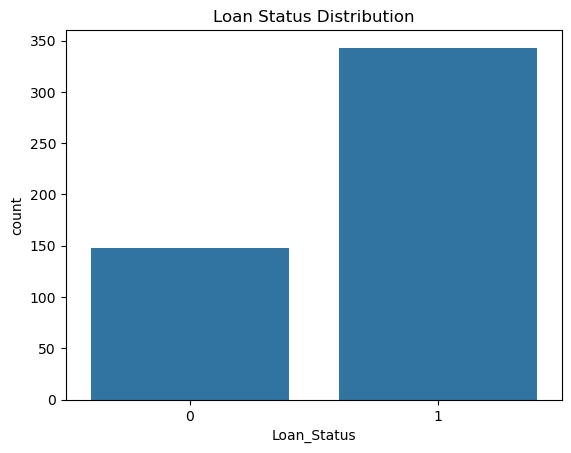

Loan_Status
1    343
0    148
Name: count, dtype: int64


In [8]:
sns.countplot(
    x="Loan_Status",
    data=df
)

plt.title("Loan Status Distribution")
plt.show()

print(df["Loan_Status"].value_counts())

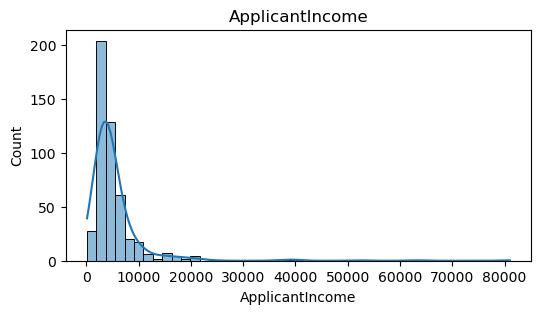

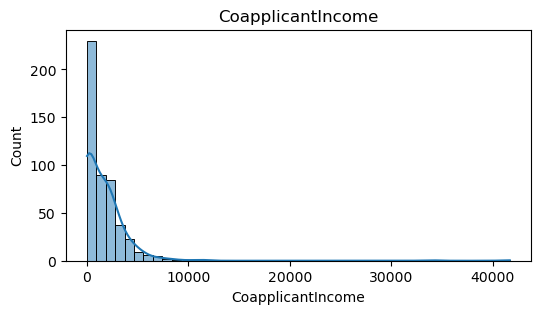

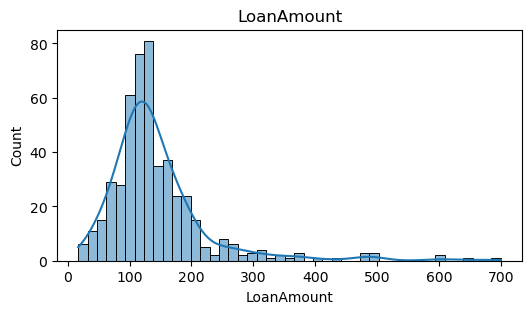

In [9]:
num_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

for col in num_features:

    plt.figure(figsize=(6,3))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

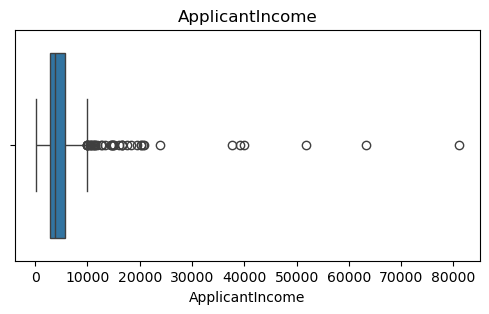

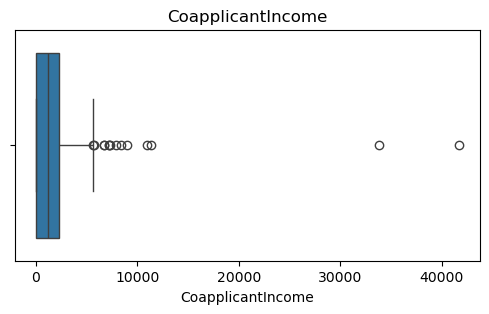

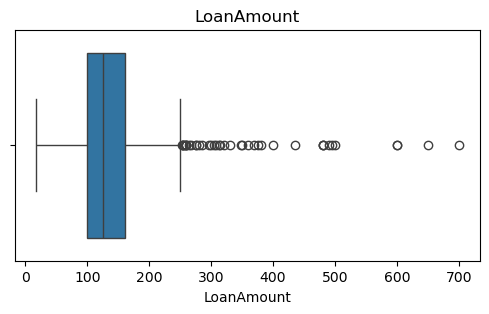

In [10]:
for col in num_features:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [11]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [12]:
df["IncomePerLoan"] = (
    df["TotalIncome"] /
    (df["LoanAmount"] + 1)
)

In [13]:
df["IncomePerLoan"] = (
    df["TotalIncome"] /
    (df["LoanAmount"] + 1)
)

In [14]:
#encoding target
df["Loan_Status"] = df["Loan_Status"].map(
    {
        "N":0,
        "Y":1
    }
)

In [15]:
#one-hot encoding
df = pd.get_dummies(
    df,
    drop_first=True
)

print(df.shape)

(491, 508)


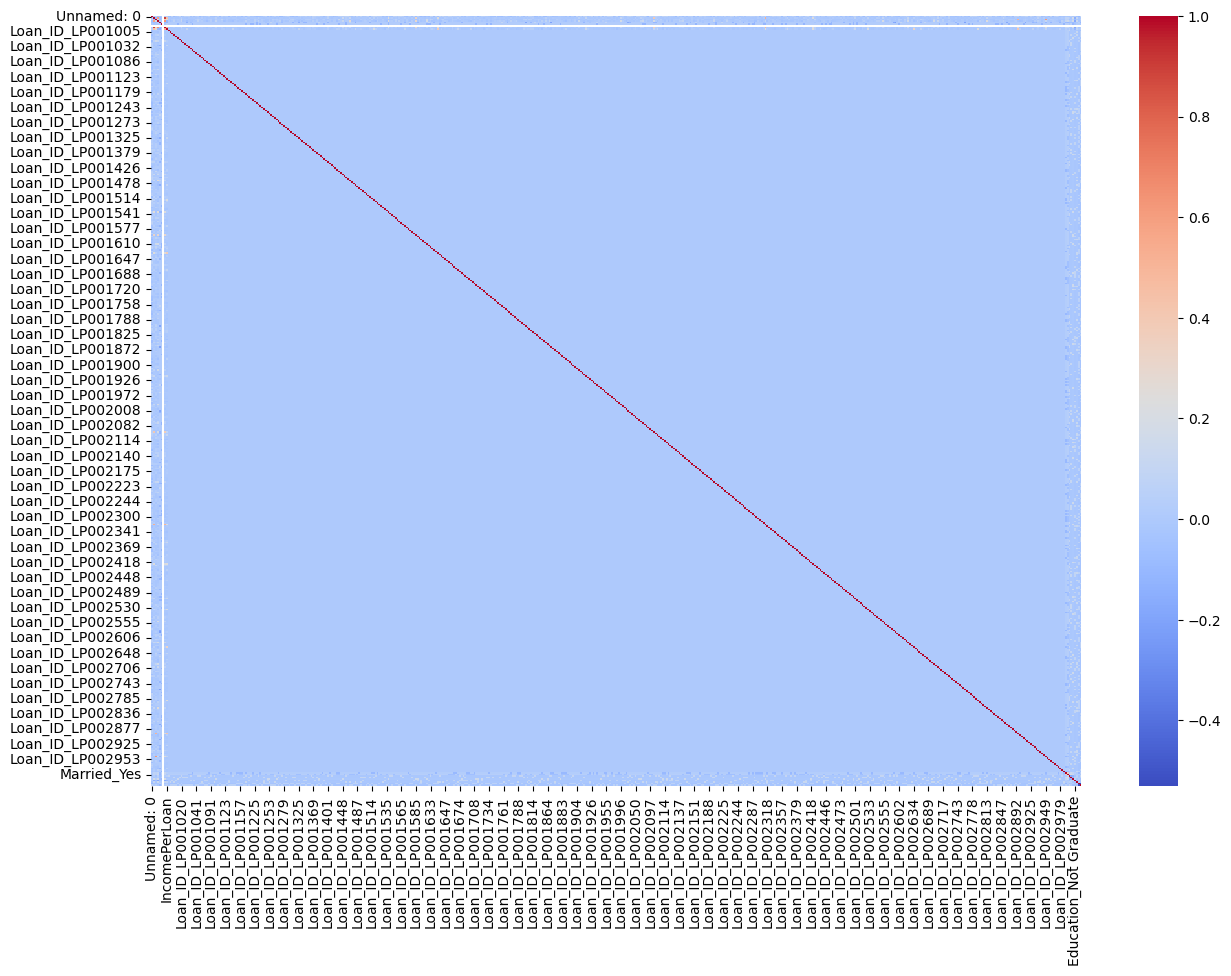

In [16]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [17]:
#train-test-split
X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

NameError: name 'X_train' is not defined

In [ ]:
lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

dt_prob = dt.predict_proba(
    X_test
)[:,1]

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [ ]:
ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

ada_pred = ada.predict(
    X_test
)

ada_prob = ada.predict_proba(
    X_test
)[:,1]

In [ ]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    print("="*50)
    print(model_name)
    print("="*50)

    print(
        "Accuracy:",
        accuracy_score(y_true,y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true,y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true,y_pred)
    )

    print(
        "F1:",
        f1_score(y_true,y_pred)
    )

    print(
        "ROC AUC:",
        roc_auc_score(y_true,y_prob)
    )

    print("\nConfusion Matrix")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

    print("\nClassification Report")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "AdaBoost",
    y_test,
    ada_pred,
    ada_prob
)

In [ ]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Average:", scores.mean())